Autoencoder :

El autoencoder del paper Scimilarity pesa unos 30G (el zip) por lo que voy a hacer uno yo que haga algo parecido.

In [ ]:
!pip install scanpy scikit-misc igraph

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 43.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.0/183.0 kB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 103.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.6/176.6 kB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 135.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.7/295.7 kB 31.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 155.1 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently t

In [ ]:
import scanpy as sc
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F
import os

archivo_local = "kang_pbmc.h5ad"

print("Descargando el dataset de Kang...")

!curl -Lo {archivo_local} "https://www.dropbox.com/s/wk5zewf2g1oat69/train_pbmc.h5ad?dl=1"

# Lo cargamos en Scanpy
print("\nCargando la matriz en memoria...")
adata = sc.read_h5ad(archivo_local)

print("\n--- Resumen del Dataset ---")
print(adata)
print("\n--- Condiciones disponibles ---")
print(adata.obs['condition'].value_counts())
print("\n--- Tipos celulares disponibles ---")
print(adata.obs['cell_type'].value_counts())

Descargando el dataset de Kang...
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   132  100   132    0     0    153      0 --:--:-- --:--:-- --:--:--   153
100    17  100    17    0     0      9      0  0:00:01  0:00:01 --:--:--     0
100   475    0   475    0     0    202      0 --:--:--  0:00:02 --:--:--  1714
100 22.4M  100 22.4M    0     0  7075k      0  0:00:03  0:00:03 --:--:-- 99.5M

Cargando la matriz en memoria...

--- Resumen del Dataset ---
AnnData object with n_obs × n_vars = 16893 × 6998
    obs: 'condition', 'n_counts', 'n_genes', 'mt_frac', 'cell_type'
    var: 'gene_symbol', 'n_cells'
    uns: 'cell_type_colors', 'condition_colors', 'neighbors'
    obsm: 'X_pca', 'X_tsne', 'X_umap'
    obsp: 'distances', 'connectivities'

--- Condiciones disponibles ---
condition
stimulated    8886
control       8007
Name: count, dtype: int64

--- Tipos celulares disponible

/usr/local/lib/python3.12/dist-packages/anndata/_io/h5ad.py:267: FutureWarning: Moving element from .uns['neighbors']['distances'] to .obsp['distances'].

This is where adjacency matrices should go now.
  return AnnData(**{
/usr/local/lib/python3.12/dist-packages/anndata/_io/h5ad.py:267: FutureWarning: Moving element from .uns['neighbors']['connectivities'] to .obsp['connectivities'].

This is where adjacency matrices should go now.
  return AnnData(**{


In [ ]:
# Seleccionamos los 2000 genes mas importantes (tenemos 7 mil)
sc.pp.highly_variable_genes(adata, n_top_genes=2000)
adata_hv = adata[:, adata.var['highly_variable']].copy()

# Guardamos el dataset para su uso en la segunda parte
from google.colab import drive

drive.mount('/content/drive')
adata_hv.write('/content/drive/MyDrive/kang_pbmc_limpio.h5ad')

# Nos quedamos solo con las celulas sanas (ya que no queremos generar celulas enfermas)
adata_sano = adata_hv[adata_hv.obs['condition'] == 'control'].copy()

# Extraer la matriz de genes
matriz_genes = adata_sano.X.toarray()
print(f"Tienes {matriz_genes.shape[0]} células y {matriz_genes.shape[1]} genes")

from sklearn.preprocessing import LabelEncoder

# Tambien extraemos y traducimos el tipo celular a números (0, 1, 2...)
le_tipo = LabelEncoder()
etiquetas_tipo = le_tipo.fit_transform(adata_sano.obs['cell_type'])

print(f"Clases a generar ({len(le_tipo.classes_)}): {le_tipo.classes_}")

Mounted at /content/drive
Tienes 8007 células y 2000 genes
Clases a generar (7): ['B' 'CD14+Mono' 'CD4T' 'CD8T' 'Dendritic' 'FCGR3A+Mono' 'NK']


Este tipo de cuelas son Células Mononucleares de Sangre Periférica , son células de tu sistema inmunitario que circulan por la sangre
- B (Linfocitos B) : Su trabajo principal es crear anticuerpos para neutralizar virus y bacterias.
- CD4T (Linfocitos T Colaboradores / Helper): No atacan directamente, sino que envían señales químicas (citocinas) para coordinar a las demás células cuando hay una infección.
-  CD8T (Linfocitos T Citotóxicos): Se encargan de buscar células que ya han sido infectadas por un virus (o células tumorales) y destruirlas
- CD14+Mono (Monocitos Clásicos): Hacen fagocitosis de los patógenos y los restos de células muertas.
- FCGR3A+Mono (Monocitos No Clásicos): Viajan por los vasos sanguíneos buscando señales de inflamación o daño.
- NK (Natural Killer): Las células NK destruyen células infectadas o cancerosas de forma innata y rapidísima.
- Dendritic (Células Dendríticas): Capturan trozos de virus o bacterias y viajan hasta los ganglios linfáticos para enseñárselos a los Linfocitos T (CD4 y CD8) para que puedan destruirlos.

In [ ]:
# Convertimos x e y a tensor
X_tensor = torch.tensor(matriz_genes, dtype=torch.float32)
y_tensor = torch.tensor(etiquetas_tipo, dtype=torch.long)

# Guardamos las clases para saber quién es el 0, el 1, etc posteriormente
clases_celulares = le_tipo.classes_

# Dataset y DataLoader
dataset = TensorDataset(X_tensor, y_tensor)

from torch.utils.data import random_split

# Dividimos los datos
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

print(f"Forma de X_tensor: {X_tensor.shape}")
print(f"Forma de y_tensor: {y_tensor.shape}")

Forma de X_tensor: torch.Size([8007, 2000])
Forma de y_tensor: torch.Size([8007])


In [ ]:
import torch
import torch.nn as nn

class AutoencoderSC(nn.Module):
    def __init__(self, n_genes=2000):
        super().__init__()
        # Encoder: Comprime la información a espacio latente
        self.encoder = nn.Sequential(
            nn.Linear(n_genes, 1024),
            nn.BatchNorm1d(1024),
            nn.SiLU(),
            nn.Dropout(0.1),


            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.SiLU(),

            nn.Linear(512,128)
        )
        # Decoder: Reconstruye los genes
        self.decoder = nn.Sequential(
            nn.Linear(128, 512),
            nn.BatchNorm1d(512),
            nn.SiLU(),

            nn.Linear(512,1024),
            nn.BatchNorm1d(1024),
            nn.SiLU(),
            nn.Dropout(0.1),

            nn.Linear(1024, n_genes)
        )

    def forward(self, x):
        z = self.encoder(x)
        x_pred = self.decoder(z)
        return x_pred, z

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
autoencoder = AutoencoderSC(n_genes=2000).to(device)
optimizer_ae = torch.optim.Adam(autoencoder.parameters(), lr=1e-4)
loss_fn_ae = nn.SmoothL1Loss()  # usamos esta y no MSE porque es menos sensible a valores extremos

epochs_ae = 180

for epoch in range(epochs_ae):
    # ENTRENAMIENTO
    autoencoder.train()
    loss_total = 0
    for x_batch, _ in train_loader:
        x_batch = x_batch.to(device)

        x_pred, z = autoencoder(x_batch)
        loss = loss_fn_ae(x_pred, x_batch)

        optimizer_ae.zero_grad()
        loss.backward()
        optimizer_ae.step()

        loss_total += loss.item()

    # VALIDACIÓN
    autoencoder.eval()
    val_loss_total = 0
    with torch.no_grad():
        for x_val, _ in test_loader:
            x_val = x_val.to(device)

            x_pred_val, _ = autoencoder(x_val)
            val_loss = loss_fn_ae(x_pred_val, x_val)

            val_loss_total += val_loss.item()


    if (epoch + 1) % 10 == 0:
        train_loss_avg = loss_total / len(train_loader)
        val_loss_avg = val_loss_total / len(test_loader)
        print(f"AE Epoch [{epoch+1}/{epochs_ae}] | Train Loss: {train_loss_avg:.4f} | Validation Loss: {val_loss_avg:.4f}")

AE Epoch [10/180] | Train Loss: 0.0151 | Validation Loss: 0.0127
AE Epoch [20/180] | Train Loss: 0.0135 | Validation Loss: 0.0120
AE Epoch [30/180] | Train Loss: 0.0127 | Validation Loss: 0.0117
AE Epoch [40/180] | Train Loss: 0.0122 | Validation Loss: 0.0114
AE Epoch [50/180] | Train Loss: 0.0123 | Validation Loss: 0.0113
AE Epoch [60/180] | Train Loss: 0.0115 | Validation Loss: 0.0109
AE Epoch [70/180] | Train Loss: 0.0115 | Validation Loss: 0.0108
AE Epoch [80/180] | Train Loss: 0.0112 | Validation Loss: 0.0106
AE Epoch [90/180] | Train Loss: 0.0110 | Validation Loss: 0.0104
AE Epoch [100/180] | Train Loss: 0.0109 | Validation Loss: 0.0103
AE Epoch [110/180] | Train Loss: 0.0104 | Validation Loss: 0.0101
AE Epoch [120/180] | Train Loss: 0.0100 | Validation Loss: 0.0099
AE Epoch [130/180] | Train Loss: 0.0101 | Validation Loss: 0.0099
AE Epoch [140/180] | Train Loss: 0.0096 | Validation Loss: 0.0097
AE Epoch [150/180] | Train Loss: 0.0096 | Validation Loss: 0.0096
AE Epoch [160/180] 

In [ ]:
class ConditionController(nn.Module):
    def __init__(self, latent_dim=128, n_clases=7):
        super(ConditionController, self).__init__()
        # Red de 4 capas (MLP)
        self.classifier = nn.Sequential(
            # Capa 1: Entrada (Latente + Timestamp)
            nn.Linear(latent_dim + 1, 512),
            nn.BatchNorm1d(512),
            nn.SiLU(),
            nn.Dropout(0.1),

            # Capa 2
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.SiLU(),
            nn.Dropout(0.1),

            # Capa 3
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.SiLU(),

            # Capa 4: Salida (Clasificación multiclase)
            nn.Linear(128, n_clases)
        )

    def forward(self, z, t):
        # El modelo recibe el timestamp t y el embedding z como inputs
        # Concatenamos z (128) con t (1) para tener una entrada de 129
        x_input = torch.cat([z, t], dim=1)
        return self.classifier(x_input)

El generador propone un cambio en el perfil de expresión génica.

Este ConditionController mira ese cambio y dice, esto se aleja de mi linaje objetivo, corrígelo.

El gradiente de este clasificador guía al generador. Básicamente, le dice al modelo de difusión hacia donde mover los niveles de expresión de estos genes en la direccion especifica para generar la celula desada.

In [ ]:
def train_step_classifier(controller, encoder, x_real, labels, optimizer, loss_fn):
    controller.train()
    optimizer.zero_grad()
    # Pasamos a latente sin gradientes en el encoder
    with torch.no_grad():
        _, z_real = encoder(x_real)

    # Solo ruido hasta T/2 (0.5) como dice el paper
    t = torch.rand((x_real.shape[0], 1)).to(device) * 0.5
    noise = torch.randn_like(z_real)
    z_noisy = (1 - t) * z_real + t * noise

    # Clasificar y optimizar (Cross Entropy)
    pred = controller(z_noisy, t)
    loss = loss_fn(pred, labels)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    return loss.item()

In [ ]:
import torch.optim as optim
num_clusters = 7
controller = ConditionController(n_clases = num_clusters).to(device)
optimizer_cc = optim.Adam(controller.parameters(), lr=1e-3)
epochs = 30
loss_fn_cc = nn.CrossEntropyLoss()
autoencoder.eval()
for epoch in range(epochs):
    # ENTRENAMIENTO
    loss_acumulada = 0
    for x_batch, labels_batch in train_loader:
        x_batch = x_batch.to(device)
        labels_batch = labels_batch.to(device)

        loss = train_step_classifier(controller, autoencoder, x_batch, labels_batch, optimizer_cc , loss_fn =loss_fn_cc)
        loss_acumulada += loss

    # FASE DE VALIDACIÓN
    controller.eval()
    val_loss_acumulada = 0
    with torch.no_grad():
        for x_val, labels_val in test_loader:
            x_val = x_val.to(device)
            labels_val = labels_val.to(device)

            # Pasamos a latente
            z_val = autoencoder.encoder(x_val)

            #  ruido
            t_val = torch.full((x_val.shape[0], 1), 0.25).to(device) # fijamos el ruido en t = 0.25 para evaluar como clasifica con ruido
            noise_val = torch.randn_like(z_val)
            z_noisy_val = (1 - t_val) * z_val + t_val * noise_val

            # Predecimos y calculamos error
            pred_val = controller(z_noisy_val, t_val)
            val_loss = loss_fn_cc(pred_val, labels_val)
            val_loss_acumulada += val_loss.item()


    if (epoch + 1) % 5 == 0:
        train_loss_avg = loss_acumulada / len(train_loader)
        val_loss_avg = val_loss_acumulada / len(test_loader)
        print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {train_loss_avg:.4f} | Validation Loss: {val_loss_avg:.4f}")

Epoch [5/30] | Train Loss: 0.5583 | Validation Loss: 0.4717
Epoch [10/30] | Train Loss: 0.5704 | Validation Loss: 0.4625
Epoch [15/30] | Train Loss: 0.5375 | Validation Loss: 0.4621
Epoch [20/30] | Train Loss: 0.5475 | Validation Loss: 0.4594
Epoch [25/30] | Train Loss: 0.5040 | Validation Loss: 0.4472
Epoch [30/30] | Train Loss: 0.5211 | Validation Loss: 0.4619


In [ ]:
import torch
import torch.nn as nn
import math

# 1. Embeddings de Tiempo
class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings

# 2. Bloque Residual Real (Dos capas lineales + Activación + BatchNorm)
class ResidualBlock(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim),
            nn.SiLU(),
            nn.Dropout(0.1),
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim),
            nn.SiLU(),
            nn.Dropout(0.1)
        )

    def forward(self, x):
        # La salida es la entrada + la transformación
        return x + self.block(x)

# 3. Red Principal (Denoising Network)
class DenoisingNetwork(nn.Module):
    def __init__(self, latent_dim, num_classes, hidden_dim= 512):
        super().__init__()

        # ENTRADAS, Proyección del espacio latente
        self.input_proj = nn.Linear(latent_dim, hidden_dim)

        # Tiempo emb
        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(hidden_dim),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
        )

        # Etiquetas
        self.label_embedding = nn.Embedding(num_classes, hidden_dim)

        # Usamos 3 bloques residuales consecutivos
        self.res_block1 = ResidualBlock(hidden_dim)
        self.res_block2 = ResidualBlock(hidden_dim)
        self.res_block3 = ResidualBlock(hidden_dim)

        # SALIDA
        self.output_layer = nn.Linear(hidden_dim, latent_dim)

    def forward(self, x, t, labels):
        # Aplana 't' a (batch_size,)
        t = t.view(-1)
        # 1. Procesar Embeddings
        x_emb = self.input_proj(x)
        t_emb = self.time_mlp(t)
        l_emb = self.label_embedding(labels)

        # 2. Sumar todo
        h = x_emb + t_emb + l_emb

        # 3. Pasar por los bloques residuales
        h = self.res_block1(h)
        h = self.res_block2(h)
        h = self.res_block3(h)

        # 4. Volver a la dimensión latente original
        return self.output_layer(h)

In [ ]:
#Escalamos los datos que salen del encoder (SOLO TRAIN para evitar data leakage)

# Extraemos SOLO los datos de entrenamiento usando los índices
X_train = X_tensor[train_dataset.indices]
y_train = y_tensor[train_dataset.indices]

autoencoder.eval()
with torch.no_grad():
    # Pasamos solo X_train por el encoder
    train_latents_raw = autoencoder.encoder(X_train.to(device)).cpu().numpy()

# Ajustar con Scaler SOLO con datos de entrenamiento
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
train_latents_norm = scaler.fit_transform(train_latents_raw)

# Guardamos los parámetros del scaler como tensores de PyTorch
scaler_mean = torch.tensor(scaler.mean_, dtype=torch.float32).to(device)
scaler_std = torch.tensor(scaler.scale_, dtype=torch.float32).to(device)

# Crear los tensores para la difusión
train_z = torch.tensor(train_latents_norm, dtype=torch.float32)
train_labels = y_train

# Crear un nuevo DataLoader exclusivo para la difusión
diffusion_dataset = TensorDataset(train_z, train_labels)
diffusion_loader = DataLoader(diffusion_dataset, batch_size= 256, shuffle=True)


In [ ]:
def train_step_denoising(denoising_model, z_batch, labels_batch, optimizer, loss_fn=nn.MSELoss()):
    denoising_model.train()
    device = z_batch.device
    batch_size = z_batch.shape[0]

    # Generamos t aleatorio y ruido
    t = torch.rand((batch_size,1)).to(device)
    epsilon = torch.randn_like(z_batch).to(device)

    # Cosine Schedule (Preserva la varianza)
    # En lugar de (1-t) y t, usamos cos y sin.
    # t va de 0 a 1. Lo mapeamos a 0 -> pi/2
    theta = t * (torch.pi / 2)

    alpha_t = torch.cos(theta) # Señal
    sigma_t = torch.sin(theta) # Ruido

    z_t = alpha_t * z_batch + sigma_t * epsilon

    # 4. Predicción
    pred_noise = denoising_model(z_t, t, labels_batch)

    # 5. Loss
    loss = loss_fn(pred_noise, epsilon)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    return loss.item()

In [ ]:
num_classes = len(torch.unique(y_tensor))
dataset = torch.utils.data.TensorDataset(train_z, train_labels)
loader = torch.utils.data.DataLoader(dataset, batch_size=64, shuffle=True)
denoising_model = DenoisingNetwork(latent_dim=128,num_classes=num_classes).to(device)
optimizer_denoise = torch.optim.Adam(denoising_model.parameters(), lr=1e-4)

import numpy as np

# PREPARAR DATOS DE VALIDACIÓN PARA DIFUSIÓN
X_val = X_tensor[test_dataset.indices]
y_val = y_tensor[test_dataset.indices]

autoencoder.eval()
with torch.no_grad():
    val_latents_raw = autoencoder.encoder(X_val.to(device)).cpu().numpy()

val_latents_norm = scaler.transform(val_latents_raw)

val_z = torch.tensor(val_latents_norm, dtype=torch.float32)
val_diffusion_dataset = torch.utils.data.TensorDataset(val_z, y_val)
val_diffusion_loader = torch.utils.data.DataLoader(val_diffusion_dataset, batch_size=64, shuffle=False)
loss_fn_denoise = nn.MSELoss()

for epoch in range(500):
    # ENTRENAMIENTO
    denoising_model.train()
    total_loss = 0
    for batch_z, batch_labels in loader:
        batch_z, batch_labels = batch_z.to(device), batch_labels.to(device)
        loss = train_step_denoising(denoising_model, batch_z, batch_labels, optimizer_denoise)
        total_loss += loss

    # VALIDACIÓN
    denoising_model.eval()
    val_total_loss = 0
    with torch.no_grad():
        for val_z_batch, val_labels_batch in val_diffusion_loader:
            val_z_batch = val_z_batch.to(device)
            val_labels_batch = val_labels_batch.to(device)

            # Replicamos ruido del train_step_denoising
            batch_size_val = val_z_batch.shape[0]
            t_val = torch.rand((batch_size_val, 1)).to(device)
            epsilon_val = torch.randn_like(val_z_batch).to(device)

            theta_val = t_val * (np.pi / 2)
            alpha_t_val = torch.cos(theta_val)
            sigma_t_val = torch.sin(theta_val)

            z_t_val = alpha_t_val * val_z_batch + sigma_t_val * epsilon_val

            # Predecir ruido
            pred_noise_val = denoising_model(z_t_val, t_val, val_labels_batch)
            val_loss = loss_fn_denoise(pred_noise_val, epsilon_val)
            val_total_loss += val_loss.item()


    if epoch % 10 == 0:
        train_loss_avg = total_loss / len(loader)
        val_loss_avg = val_total_loss / len(val_diffusion_loader)
        print(f"Epoch {epoch} | Train Loss: {train_loss_avg:.4f} | Validation Loss: {val_loss_avg:.4f}")

Epoch 0 | Train Loss: 1.1457 | Validation Loss: 0.9018
Epoch 10 | Train Loss: 0.4671 | Validation Loss: 0.3885
Epoch 20 | Train Loss: 0.4062 | Validation Loss: 0.3508
Epoch 30 | Train Loss: 0.3830 | Validation Loss: 0.3207
Epoch 40 | Train Loss: 0.3602 | Validation Loss: 0.3103
Epoch 50 | Train Loss: 0.3421 | Validation Loss: 0.2920
Epoch 60 | Train Loss: 0.3366 | Validation Loss: 0.3190
Epoch 70 | Train Loss: 0.3267 | Validation Loss: 0.3037
Epoch 80 | Train Loss: 0.3172 | Validation Loss: 0.2800
Epoch 90 | Train Loss: 0.3210 | Validation Loss: 0.2755
Epoch 100 | Train Loss: 0.3144 | Validation Loss: 0.3004
Epoch 110 | Train Loss: 0.3150 | Validation Loss: 0.2609
Epoch 120 | Train Loss: 0.3069 | Validation Loss: 0.2893
Epoch 130 | Train Loss: 0.3119 | Validation Loss: 0.2679
Epoch 140 | Train Loss: 0.3120 | Validation Loss: 0.2642
Epoch 150 | Train Loss: 0.2974 | Validation Loss: 0.2628
Epoch 160 | Train Loss: 0.3022 | Validation Loss: 0.2707
Epoch 170 | Train Loss: 0.2975 | Validatio

Autoencoder: Crea el "mapa" (espacio latente de 128D).



Condition Controller: Aprende a leer ese mapa incluso con ruido (guía).



Denoising Network: Aprende a "limpiar" cualquier punto del mapa para que se convierta en una célula real.

In [ ]:
def generate_cells(target_class, n_cells, denoising_model, controller, autoencoder, latent_dim=128, guidance_scale= 15):
    denoising_model.eval()
    controller.eval()
    autoencoder.eval()

    device = next(denoising_model.parameters()).device

    # Empezamos con puro ruido aleatorio en el espacio latente (z)
    z_t = torch.randn((n_cells, latent_dim)).to(device)
    # Definimos el tipo de célula que queremos (repetido n veces)
    labels = torch.full((n_cells,), target_class, dtype=torch.long).to(device)


    # Simulamos 100 pasos de limpieza
    steps = 1000
    dt = 1.0 / steps

    for i in range(steps):
        # Tiempo actual (de 1 a 0)
        t_val = 1.0 - (i * dt)
        t = torch.full((n_cells, 1), t_val).to(device)

        # Guia de gradiente : Le va indicando al modelo en cada paso hacia lo que se tiene que parecer
        z_t.requires_grad_(True)

        # El clasificador nos dice qué tan cerca estamos de la clase deseada
        logits = controller(z_t, t)
        loss = nn.CrossEntropyLoss()(logits, labels)

        # Calculamos el gradiente,hacia dónde tengo que mover z para ser más 'target_class'
        grads = torch.autograd.grad(loss, z_t)[0]
        # Normalizamos el gradiente para que tenga una escala similar al ruido
        # Esto asegura que el guidance_scale sea efectivo
        grads = grads / (torch.norm(grads) + 1e-8) # Normalizamos

        # DENOISING
        with torch.no_grad():
            noise_pred = denoising_model(z_t, t,labels)

            # Combinamos: Limpieza de ruido + Empuje del gradiente
            z_t = z_t.detach() - (noise_pred * dt) - (guidance_scale * grads * dt)


    # Decodificar: De 128 volvemos a los 2000 genes originales
    with torch.no_grad():
        # Multiplicamos por la desviación estándar y sumamos la media para que en el UMAP no queden tan apelotonados
        z_t_unscaled = (z_t * scaler_std) + scaler_mean

        # Le pasamos al decoder
        genes_sinteticos = autoencoder.decoder(z_t_unscaled)

    return genes_sinteticos.cpu().numpy()

In [ ]:
# 1. Generamos células de todos los tipos (por ejemplo, 100 de cada uno)
matriz_sintetica = []
labels_sinteticas = []
n = 100
for i in range(num_clusters):
    print(f"Generando cluster {i + 1}...")
    sinteticas = generate_cells(i, n, denoising_model, controller, autoencoder)
    matriz_sintetica.append(sinteticas)
    labels_sinteticas.extend([f"Sintetica_{i}"] * n)

Generando cluster 1...
Generando cluster 2...
Generando cluster 3...
Generando cluster 4...
Generando cluster 5...
Generando cluster 6...
Generando cluster 7...



--- Análisis de Sparsity ---
% de Ceros en Real: 95.59%
% de Ceros en Sintética (ANTES): 0.00%
% de Ceros en Sintética (DESPUÉS): 80.39%

Genes listos para PCA: 2000
Células totales: 8707
Ejecutando PCA...


/usr/lib/python3.12/functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


Calculando Vecinos...
Generando UMAP...


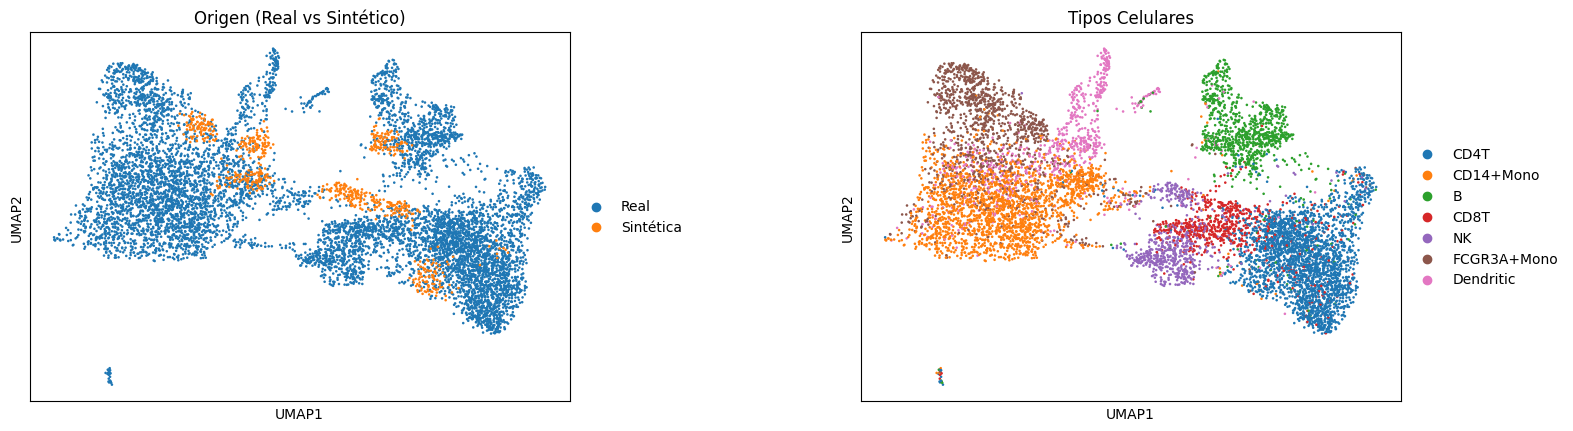

In [ ]:
import pandas as pd
import numpy as np

# Preparamos el objeto SINTÉTICO con tus nuevas variables
matriz_sintetica_np = np.vstack(matriz_sintetica)

clases = le_tipo.classes_

# 1. Comparamos el porcentaje de ceros (Sparsity)
ceros_real = np.mean(matriz_genes == 0) * 100
ceros_synth = np.mean(matriz_sintetica_np == 0) * 100
print(f"\n--- Análisis de Sparsity ---")
print(f"% de Ceros en Real: {ceros_real:.2f}%")
print(f"% de Ceros en Sintética (ANTES): {ceros_synth:.2f}%")

# 2. Aplicamos un umbral pequeño para forzar los ceros biológicos
umbral = 0.05
matriz_sintetica_np = np.where(matriz_sintetica_np < umbral, 0, matriz_sintetica_np)

print(f"% de Ceros en Sintética (DESPUÉS): {np.mean(matriz_sintetica_np == 0) * 100:.2f}%\n")

# 2. Creamos el AnnData SINTÉTICO
adata_synth = sc.AnnData(X=matriz_sintetica_np)
adata_synth.var_names = adata_sano.var_names # Sincronizamos genes

# Mapeamos los números generados a los nombres de las células
nombres_asignados = [clases[int(str(label).split('_')[-1])] for label in labels_sinteticas]

adata_synth.obs['tipo_celular'] = pd.Categorical(nombres_asignados)
adata_synth.obs['origen'] = 'Sintética'
adata_synth.obs_names = [f"cell_synth_{i}" for i in range(adata_synth.n_obs)]


# 3. Preparamos el objeto REAL
adata_real = adata_sano.copy()
adata_real.obs['origen'] = 'Real'
adata_real.obs['tipo_celular'] = adata_real.obs['cell_type']


# 4. CONCATENAR
adata_total = sc.concat([adata_real, adata_synth])

print(f"Genes listos para PCA: {adata_total.n_vars}")
print(f"Células totales: {adata_total.n_obs}")


# 5. Pipeline de visualización Scanpy
adata_total.X = adata_total.X.astype('float32')
sc.pp.scale(adata_total)

print("Ejecutando PCA...")
sc.tl.pca(adata_total, n_comps=50)

print("Calculando Vecinos...")
sc.pp.neighbors(adata_total, n_neighbors=15, n_pcs=50)

print("Generando UMAP...")
sc.tl.umap(adata_total)


# 6. Gráfico Final: Compara el origen y el tipo de célula
sc.pl.umap(adata_total, color=['origen', 'tipo_celular'],
           title=['Origen (Real vs Sintético)', 'Tipos Celulares'],
           wspace=0.4)

/usr/local/lib/python3.12/dist-packages/scanpy/plotting/_utils.py:509: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list
/usr/local/lib/python3.12/dist-packages/scanpy/plotting/_utils.py:509: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


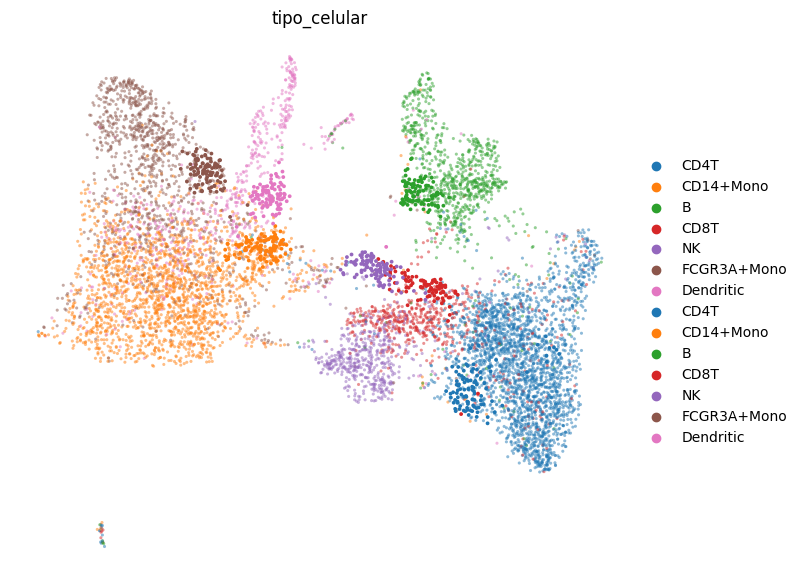

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Colores

if 'tipo_celular_colors' in adata_total.uns:
    colores_base = adata_total.uns['tipo_celular_colors']
else:
    # Si no, usamos una paleta estándar
    colores_base = sns.color_palette("husl", len(adata_total.obs['tipo_celular'].unique()))

fig, ax = plt.subplots(figsize=(8, 7))


# Reales
sc.pl.umap(
    adata_total[adata_total.obs['origen'] == 'Real'],
    color='tipo_celular',
    ax=ax,
    show=False,
    alpha=0.5,
    title="Validación: Real (Opaco) vs Sintético (Transparente)",
    palette=colores_base,
    frameon=False,
    size = 20
)

# sinteticas
sc.pl.umap(
    adata_total[adata_total.obs['origen'] == 'Sintética'],
    color='tipo_celular',
    ax=ax,
    show=False,
    alpha=1,
    palette=colores_base,
    frameon=False,
    size = 30
)

plt.show()

In [ ]:
import torch.nn.functional as F

def diagnostico_clasificador(controller, encoder, dataloader, device):
    controller.eval()
    encoder.eval()

    correctos = 0
    total = 0
    probabilidades_medias = []

    with torch.no_grad():
        for x_batch, labels_batch in dataloader:
            x_batch, labels_batch = x_batch.to(device), labels_batch.to(device)

            # 1. Pasamos por el encoder (z real)
            _, z_real = encoder(x_batch)

            # 2. Evaluamos en t=0 (sin ruido, el escenario más fácil)
            t_cero = torch.zeros((x_batch.shape[0], 1)).to(device)
            logits = controller(z_real, t_cero)

            # 3. Calculamos probabilidades con Softmax
            probs = F.softmax(logits, dim=1)
            predicciones = torch.argmax(probs, dim=1)

            # 4. Métricas
            correctos += (predicciones == labels_batch).sum().item()
            total += labels_batch.size(0)

            # Guardamos la probabilidad que le dio a la clase correcta
            prob_clase_correcta = probs.gather(1, labels_batch.view(-1, 1))
            probabilidades_medias.append(prob_clase_correcta.mean().item())

    accuracy = 100 * correctos / total
    confianza_media = sum(probabilidades_medias) / len(probabilidades_medias)

    print(f"Precisión en datos reales (t=0): {accuracy:.2f}%")
    print(f"Confianza media en la clase correcta: {confianza_media:.4f}")



# Ejecutar diagnóstico
diagnostico_clasificador(controller, autoencoder, test_loader, device)

Precisión en datos reales (t=0): 87.95%
Confianza media en la clase correcta: 0.8085


Correlación media (Real vs Sintética): 0.6782
Correlación media (Real vs Real):      0.5026


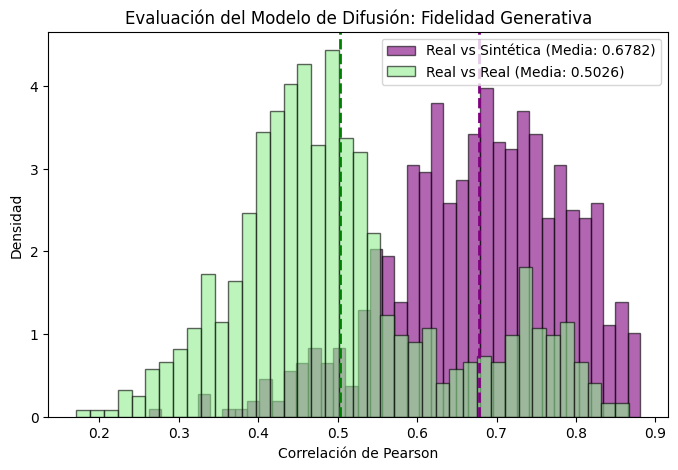

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# =================================================================
# 1. OBETENEMOS LAS MATRICES EXACTAS Y CORREGIDAS
# =================================================================
# A. Células Reales (las sacamos de adata_filtrado para asegurar que son las mismas)
if hasattr(adata_sano.X, "toarray"):
    x_real_np = adata_sano.X.toarray()
else:
    x_real_np = adata_sano.X

# B. Células Sintéticas (usamos matriz_sintetica_np que YA tiene el 86% de ceros)
x_synth_np = matriz_sintetica_np

n_real = x_real_np.shape[0]
n_synth = x_synth_np.shape[0]

# --- CORRELACIÓN REAL VS SINTÉTICA (DIFUSIÓN) ---
correlaciones_rs = []
for i in range(n_synth):
    idx_real = np.random.randint(0, n_real)
    corr = np.corrcoef(x_synth_np[i], x_real_np[idx_real])[0, 1]
    if not np.isnan(corr):
        correlaciones_rs.append(corr)

# --- CORRELACIÓN REAL VS REAL (LÍMITE BIOLÓGICO) ---
correlaciones_rr = []
for _ in range(n_synth):
    idx1, idx2 = np.random.choice(n_real, 2, replace=False)
    corr = np.corrcoef(x_real_np[idx1], x_real_np[idx2])[0, 1]
    if not np.isnan(corr):
        correlaciones_rr.append(corr)

# Calculamos medias
media_rs = np.mean(correlaciones_rs)
media_rr = np.mean(correlaciones_rr)

print(f"Correlación media (Real vs Sintética): {media_rs:.4f}")
print(f"Correlación media (Real vs Real):      {media_rr:.4f}")

# Gráfico de Evaluación de Difusión
plt.figure(figsize=(8, 5))
plt.hist(correlaciones_rs, bins=40, alpha=0.6, color='purple', edgecolor='black', density=True,
         label=f'Real vs Sintética (Media: {media_rs:.4f})')
plt.hist(correlaciones_rr, bins=40, alpha=0.6, color='lightgreen', edgecolor='black', density=True,
         label=f'Real vs Real (Media: {media_rr:.4f})')

plt.axvline(media_rs, color='purple', linestyle='dashed', linewidth=2)
plt.axvline(media_rr, color='green', linestyle='dashed', linewidth=2)

plt.title('Evaluación del Modelo de Difusión: Fidelidad Generativa')
plt.xlabel('Correlación de Pearson')
plt.ylabel('Densidad')
plt.legend()
plt.show()

Como se observa en la métrica de correlación de Pearson, las células sintéticas generadas presentan una correlación intra-muestra superior a la biológica (0.67 vs 0.5). Esto indica que el modelo de difusión, al mapear el espacio latente, actúa como un imputador de datos, eliminando el ruido técnico (dropouts) inherente a la tecnología scRNA-seq y generando perfiles transcriptómicos 'idealizados' o suavizados

In [ ]:
# Vamos a guardar el AE para poder exportarlo al siguiente paso

import torch


ruta_guardado = '/content/drive/MyDrive/pesos_autoencoder.pth'

torch.save(autoencoder.state_dict(), ruta_guardado)

print(f"Autoencoder guardado en: {ruta_guardado}")


Autoencoder guardado en: /content/drive/MyDrive/pesos_autoencoder.pth


In [ ]:
# Vamos a generar 1000 celulas B para usarlas en el siguiente paso
n = 1000
B_sinteticas = generate_cells(0, n, denoising_model, controller, autoencoder)  # tipo 0 es el B
print(B_sinteticas.shape)

ruta_guardado = '/content/drive/MyDrive/celulas_B_sinteticas_sanas.npy'

np.save(ruta_guardado, B_sinteticas)
print(f"Matriz de {B_sinteticas.shape} guardada en tu Drive.")

(1000, 2000)
Matriz de (1000, 2000) guardada en tu Drive.
